In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [4]:
# Define State
class GenerateBlog(TypedDict):
    title:str
    outline:str
    blog:str

In [5]:
def create_outline(state: GenerateBlog) -> GenerateBlog:
    # fetch the title
    title = state['title']

    # call the llm
    prompt = f"Generate a detail outline for a blog on the topic {title}"
    outline = model.invoke(prompt).content
    
    # update the outline state
    state['outline'] = outline

    return state 


def create_blog(state: GenerateBlog) -> GenerateBlog:
    # fetch the title
    title = state['title']
    outline = state['outline']

    # call the llm
    prompt = f"Generate a detail blog on the title {title} using the following outline {outline}"
    blog = model.invoke(prompt).content
    
    # update the outline state
    state['blog'] = blog

    return state 

In [6]:
# Define Graph
graph = StateGraph(GenerateBlog)

# add node from the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# add edge from the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# Compile the graph
workflow = graph.compile()

In [8]:
initial_state = {'title': 'Rise of Ai in Pakistan'}

final_state = workflow.invoke(initial_state)

print(final_state)
print(final_state['outline'])
print(final_state['blog'])

{'title': 'Rise of Ai in Pakistan', 'outline': '**Title:** "The Rise of AI in Pakistan: Opportunities and Challenges"\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Contextualizing AI\'s potential impact on Pakistan\'s economy and society\n* Thesis statement: The rise of AI in Pakistan presents both promising opportunities and significant challenges that the country must address.\n\n**II. Current State of AI in Pakistan**\n\n* Overview of Pakistan\'s existing AI infrastructure, including:\n\t+ Research institutions and universities\n\t+ AI startups and companies\n\t+ Government initiatives and policies supporting AI development\n* Discussion of the country\'s AI talent pool and potential for innovation\n\n**III. Opportunities of AI in Pakistan**\n\n* Economic benefits:\n\t+ Increased competitiveness in industries like healthcare, finance, and education\n\t+ Job creation and skill enhancement for workers\n\t+ Improved pr

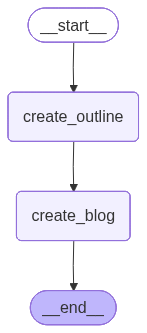

In [9]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())